In [13]:
import os, json, warnings, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy.sparse import csr_matrix, load_npz

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score)
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)

C = {
    'primary':'#4361EE','secondary':'#3A0CA3','accent':'#F72585',
    'teal':'#4CC9F0','green':'#06D6A0','orange':'#FB8500',
    'yellow':'#FFD166','red':'#EF233C','purple':'#7209B7',
    'gray':'#6C757D','light':'#F8F9FA','dark':'#1A1A2E',
}
CLUSTER_PALETTE = [
    '#4361EE','#F72585','#06D6A0','#FB8500','#4CC9F0',
    '#7209B7','#EF233C','#FFD166','#3A0CA3','#06D6A0',
    '#6C757D','#1A1A2E',
]
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'font.size':11,
    'axes.titlesize':13,'axes.titleweight':'bold',
})
FIGURE_DPI = 130

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
CFG = {
    'drive_base':    '/content/drive/MyDrive/CareerSegmentation',
    'k_range':       range(5, 13),        # Cari best K (5 sampai 12)
    'n_init':        15,                  # KMeans restarts supaya gak kena local minima
    'max_iter':      500,                 # Iterasi K-Means supaya konvergen
    'random_state':  42,                  # Reproducability
    'silhouette_sample': 5000,            # sub-sample for speed
}
CFG['out_dir']       = f"{CFG['drive_base']}/Outputs"
CFG['artifacts_dir'] = f"{CFG['out_dir']}/artifacts"
CFG['processed_dir'] = f"{CFG['out_dir']}/processed"
CFG['models_dir']    = f"{CFG['out_dir']}/models"

os.makedirs(CFG['models_dir'], exist_ok=True)

# **Load Processed Artifacts**

In [16]:
def load_artifacts(cfg):
    p = cfg['processed_dir']
    a = cfg['artifacts_dir']

    print("Loaded Artifacts:")

    # Binary matrix (sparse)
    X_binary = load_npz(f"{p}/X_binary.npz").toarray().astype(np.float32)
    print(f"  X_binary       : {X_binary.shape}")

    # SVD
    X_svd   = np.load(f"{p}/X_svd.npy")
    print(f"  X_svd          : {X_svd.shape}")

    # UMAP
    X_umap = np.load(f"{p}/X_umap.npy")
    print(f"  X_umap         : {X_umap.shape}")

    # Metadata & feature names
    df_meta       = pd.read_csv(f"{p}/df_meta_clean.csv")
    respondent_ids = np.load(f"{p}/respondent_ids.npy")
    feature_names  = json.load(open(f"{a}/feature_names.json"))

    print(f"  df_meta        : {df_meta.shape}")
    print(f"  feature_names  : {len(feature_names)} features")


    return {
        'X_binary':    X_binary,
        'X_svd':       X_svd,
        'X_umap':      X_umap,
        'df_meta':     df_meta,
        'resp_ids':    respondent_ids,
        'feat_names':  feature_names,
    }

data = load_artifacts(CFG)

Loaded Artifacts:
  X_binary       : (23387, 186)
  X_svd          : (23387, 70)
  X_umap         : (23387, 15)
  df_meta        : (23387, 12)
  feature_names  : 186 features


In [17]:
DEVTYPE_REMAP = {
    'Developer, full-stack':                       'Full-Stack',
    'Developer, back-end':                         'Back-End',
    'Developer, front-end':                        'Front-End',
    'AI/ML engineer':                              'AI/ML',
    'Developer, AI apps or physical AI':           'AI/ML',
    'Applied scientist':                           'AI/ML',
    'Data scientist':                              'Data Sci',
    'Data engineer':                               'Data Eng',
    'Data or business analyst':                    'Data Sci',
    'Developer, mobile':                           'Mobile',
    'DevOps engineer or professional':             'DevOps',
    'Cloud infrastructure engineer':               'DevOps',
    'System administrator':                        'DevOps',
    'Developer, embedded applications or devices': 'Embedded',
    'Architect, software or solutions':            'Architect',
    'Engineering manager':                         'Mgmt',
    'Student':                                     'Student',
    'Academic researcher':                         'Research',
    'Developer, game or graphics':                 'Game Dev',
}

def get_primary_role(devtype_str):
    if pd.isna(devtype_str):
        return 'Other'
    for role, short in DEVTYPE_REMAP.items():
        if role in str(devtype_str):
            return short
    return 'Other'

def purity_score(labels, primary_roles):
    total_correct = 0
    for c in np.unique(labels):
        mask  = labels == c
        roles = np.array(primary_roles)[mask]
        if len(roles) == 0:
            continue
        most_common_count = Counter(roles).most_common(1)[0][1]
        total_correct += most_common_count
    return total_correct / len(labels)

def per_cluster_purity(labels, primary_roles):
    rows = []
    for c in sorted(np.unique(labels)):
        mask   = labels == c
        roles  = np.array(primary_roles)[mask]
        counts = Counter(roles)
        dom_role, dom_count = counts.most_common(1)[0]
        rows.append({
            'cluster':      c,
            'size':         mask.sum(),
            'size_pct':     mask.sum() / len(labels) * 100,
            'dom_role':     dom_role,
            'purity':       dom_count / mask.sum(),
            'top3_roles':   counts.most_common(3),
        })
    return rows

def evaluate_clustering(X, labels, primary_roles, cfg, sample_n=None):
    sample_n = sample_n or cfg['silhouette_sample']
    n = len(labels)

    # Internal metrics
    sil = silhouette_score(X, labels,                           # Mirip dengan cluster sendiri dibanding cluster lain (-1 - 1, higher better)
                           sample_size=min(sample_n, n),
                           random_state=cfg['random_state'])
    dbi = davies_bouldin_score(X, labels)                       # Cluster padat dan jarak antar cluster jauh (0 - inf, lower better)
    ch  = calinski_harabasz_score(X, labels)                    # Cluster padat dan terpisah satu sama lain dengan batas jelas (higher better)

    # Cluster balance (distribusi data tiap cluster)
    sizes    = np.bincount(labels)
    min_pct  = sizes.min() / n * 100
    max_pct  = sizes.max() / n * 100
    balanced = (min_pct >= 3.0) and (max_pct <= 40.0)

    # Purity (Kebenaran hasil cluster berdasarkan DevType (0 -1, higher better))
    pur = purity_score(labels, primary_roles)

    # ARI (Konsistensi clustering dengan label asli (-1 - 1, higher better))
    label_ids = np.array([list(DEVTYPE_REMAP.values()).index(r)
                          if r in DEVTYPE_REMAP.values() else -1
                          for r in primary_roles])
    ari = adjusted_rand_score(label_ids, labels)

    return {
        'silhouette':    round(sil,  4),
        'davies_bouldin':round(dbi,  4),
        'calinski':      round(ch,   1),
        'purity':        round(pur,  4),
        'ari':           round(ari,  4),
        'n_clusters':    len(np.unique(labels)),
        'min_cluster_pct': round(min_pct, 1),
        'max_cluster_pct': round(max_pct, 1),
        'balanced':      balanced,
        'sizes':         sizes.tolist(),
    }

primary_roles = data['df_meta']['DevType'].apply(get_primary_role).values

# **KMeans**

In [18]:
def sweep_kmeans(X, primary_roles, cfg, label='KMeans-UMAP'):
    records = []
    print(f"  SWEEP: {label}")
    print(f"  {'K':>3}  {'Inertia':>10}  {'Silhouette':>11}  "
          f"{'DBI':>8}  {'Purity':>8}  {'ARI':>7}  {'Balance':>9}")

    best_composite = -np.inf
    best_k_composite = None

    for k in cfg['k_range']:
        km = KMeans(
            n_clusters   = k,
            n_init       = cfg['n_init'],
            max_iter     = cfg['max_iter'],
            random_state = cfg['random_state'],
            algorithm    = 'lloyd',
        )
        labels = km.fit_predict(X)

        m = evaluate_clustering(X, labels, primary_roles, cfg)
        m['k']       = k
        m['inertia'] = round(km.inertia_, 1)
        m['model']   = label
        m['km_obj']  = km        # store fitted model
        m['labels']  = labels    # store labels
        records.append(m)

        bal_flag = '[V]' if m['balanced'] else '[!]'
        print(f"  {k:>3}  {m['inertia']:>10,.0f}  {m['silhouette']:>11.4f}  "
              f"{m['davies_bouldin']:>8.4f}  {m['purity']:>8.4f}  "
              f"{m['ari']:>7.4f}  {bal_flag} {m['min_cluster_pct']:4.1f}–{m['max_cluster_pct']:4.1f}%  ")

    # Composite = gabungan silhouette, DBI, purity
    df_res = pd.DataFrame([{k2: v for k2, v in r.items()
                             if k2 not in ['km_obj','labels']}
                            for r in records])
    sil_min, sil_max = df_res['silhouette'].min(), df_res['silhouette'].max()
    dbi_min, dbi_max = df_res['davies_bouldin'].min(), df_res['davies_bouldin'].max()
    pur_min, pur_max = df_res['purity'].min(), df_res['purity'].max()

    for r in records:
        sil_n = (r['silhouette'] - sil_min) / max(sil_max - sil_min, 1e-9)
        dbi_n = 1 - (r['davies_bouldin'] - dbi_min) / max(dbi_max - dbi_min, 1e-9)
        pur_n = (r['purity'] - pur_min) / max(pur_max - pur_min, 1e-9)
        r['composite'] = round((sil_n + dbi_n + pur_n) / 3, 4)

    best_r = max(records, key=lambda x: x['composite'])
    print(f"\nBest composite score: K={best_r['k']}  "
          f"(Sil={best_r['silhouette']:.4f}, DBI={best_r['davies_bouldin']:.4f}, "
          f"Purity={best_r['purity']:.4f})")

    return records

## **KMeans UMAP**

In [19]:
records_umap = sweep_kmeans(data['X_umap'], primary_roles, CFG, label='KMeans-UMAP')

  SWEEP: KMeans-UMAP
    K     Inertia   Silhouette       DBI    Purity      ARI    Balance
    5      27,162       0.3854    1.0900    0.3639   0.0314  [V] 14.3–23.6%  
    6      22,605       0.4049    0.9683    0.3664   0.0321  [V] 13.6–21.8%  
    7      20,385       0.3460    1.0486    0.3667   0.0219  [V] 10.9–18.1%  
    8      18,509       0.3354    1.0771    0.3657   0.0208  [V] 10.5–16.5%  
    9      17,028       0.3352    1.0690    0.3663   0.0190  [V]  6.9–15.9%  
   10      15,723       0.3451    1.0527    0.3664   0.0166  [V]  3.4–16.3%  
   11      14,524       0.3301    1.0852    0.3634   0.0229  [V]  3.6–13.2%  
   12      13,710       0.3133    1.1208    0.3682   0.0212  [V]  3.5–11.4%  

Best composite score: K=6  (Sil=0.4049, DBI=0.9683, Purity=0.3664)


## **KMeans SVD**

In [20]:
records_svd = sweep_kmeans(data['X_svd'], primary_roles, CFG, label='KMeans-SVD')

  SWEEP: KMeans-SVD
    K     Inertia   Silhouette       DBI    Purity      ARI    Balance
    5     273,436       0.0333    3.6019    0.3731   0.0346  [V] 12.1–24.3%  
    6     268,577       0.0322    3.4132    0.3653   0.0329  [V] 10.3–20.8%  
    7     264,302       0.0318    3.3026    0.3633   0.0266  [V]  8.6–18.7%  
    8     261,111       0.0316    3.3762    0.3620   0.0262  [V]  5.5–17.3%  
    9     257,988       0.0284    3.3784    0.3691   0.0202  [V]  4.6–17.8%  
   10     255,211       0.0225    3.4177    0.3736   0.0247  [V]  3.5–14.4%  
   11     253,030       0.0211    3.3489    0.3702   0.0267  [V]  3.0–13.8%  
   12     250,972       0.0233    3.3649    0.3810   0.0285  [!]  3.0–12.1%  

Best composite score: K=12  (Sil=0.0233, DBI=3.3649, Purity=0.3810)


# **Model Selection**

## Elbow

In [21]:
def plot_elbow(records, cfg, title, ylabel, cost_key, color, C):
    fig, ax = plt.subplots(figsize=(8, 6))

    if not records:
        ax.text(0.5, 0.5, 'Model not run', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color=C['gray'])
        ax.set_title(title)
    else:
        ks   = [r['k'] for r in records]
        vals = [r.get(cost_key, r.get('inertia', 0)) for r in records]

        ax.plot(ks, vals, 'o-', color=color, lw=2.5, ms=7)
        ax.fill_between(ks, vals, alpha=0.08, color=color)
        ax.set_title(f'{title}\nElbow Plot', fontsize=14, fontweight='bold')
        ax.set_xlabel('K'); ax.set_ylabel(ylabel)
        ax.set_xticks(ks)

        # Highlight elbow (largest 2nd derivative)
        if len(vals) >= 3:
            diffs2 = np.diff(np.diff(vals))
            elbow_k = ks[1 + int(np.argmax(diffs2))]
            ax.axvline(elbow_k, color=C['accent'], ls='--', lw=1.5,
                       label=f'Elbow ≈ K={elbow_k}')
            ax.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

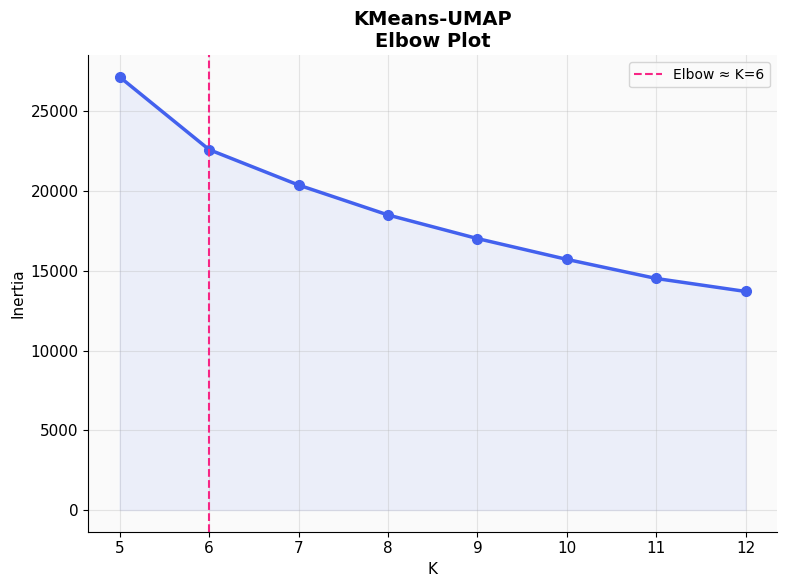

In [22]:
plot_elbow(records_umap, CFG, 'KMeans-UMAP', 'Inertia', 'inertia', C['primary'], C)

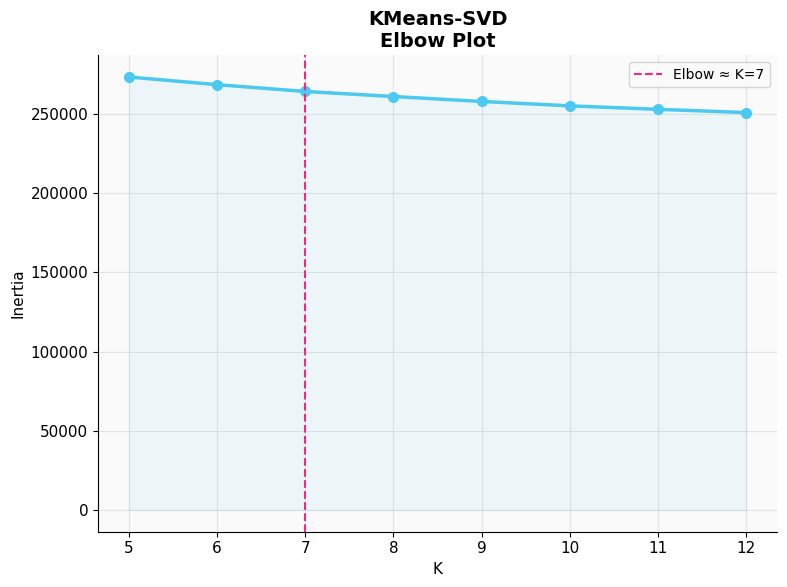

In [23]:
plot_elbow(records_svd, CFG, 'KMeans-SVD', 'Inertia', 'inertia', C['teal'], C)

## Metric Plot

In [24]:
def plot_multimodel_metric(records_dict, metric_key, title, ylabel, cfg, C, higher_better=True, ylim=None):
    fig, ax = plt.subplots(figsize=(10, 6))

    styles = {
        'KMeans-UMAP':   {'color': C.get('primary', 'blue'), 'marker': 'o'},
        'KMeans-SVD':    {'color': C.get('teal', 'teal'),    'marker': 's'},
    }

    for model_name, records in records_dict.items():
        if not records:
            continue

        if len(records) > 0 and metric_key not in records[0]:
            continue

        ks   = [r['k'] for r in records]
        vals = [r.get(metric_key) for r in records]

        if any(v is None for v in vals):
            continue

        style = styles.get(model_name, {'color': 'gray', 'marker': 'x'})

        ax.plot(ks, vals, f"{style['marker']}-", color=style['color'], lw=2.5, ms=8, label=model_name)

        best_idx = np.argmax(vals) if higher_better else np.argmin(vals)
        best_k   = ks[best_idx]
        best_val = vals[best_idx]

        ax.scatter(best_k, best_val, color=style['color'], s=140, zorder=5,
                   edgecolors=C.get('accent'), linewidths=1.5)

        if not higher_better:
            ax.axvline(best_k, color=style['color'], ls='--', lw=1, alpha=0.4)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('K', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(list(cfg['k_range']))
    ax.legend(fontsize=10)

    if ylim:
        ax.set_ylim(ylim)

    if metric_key == 'silhouette':
        ax.axhline(0, color=C.get('gray', 'gray'), ls=':', lw=1, alpha=0.5)

    plt.tight_layout()
    plt.show()

In [25]:
all_records = {
    'KMeans-UMAP': records_umap,
    'KMeans-SVD': records_svd,
}

### Silhouette

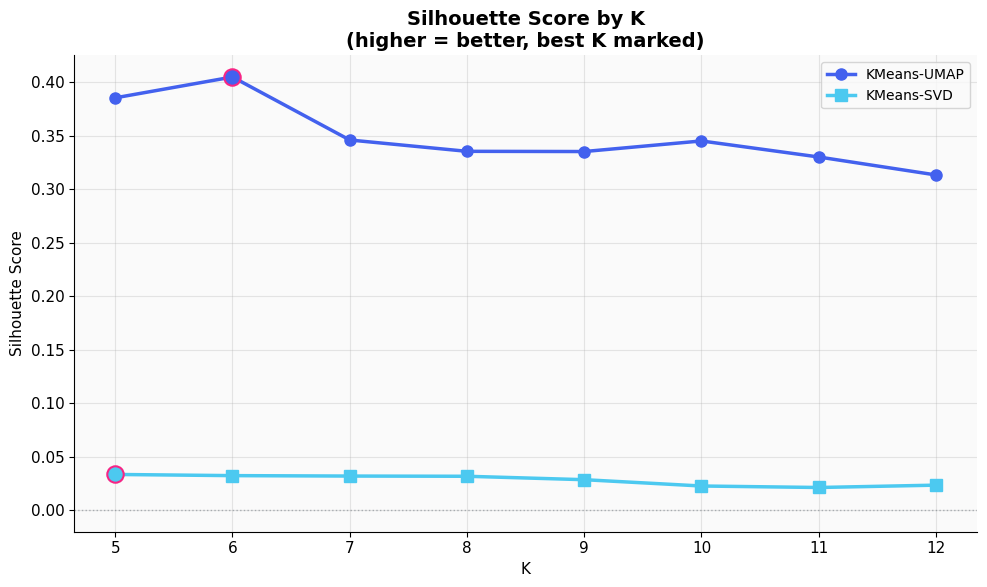

In [27]:
plot_multimodel_metric(
    records_dict=all_records,
    metric_key='silhouette',
    title='Silhouette Score by K\n(higher = better, best K marked)',
    ylabel='Silhouette Score',
    cfg=CFG, C=C,
    higher_better=True
)

### DBI

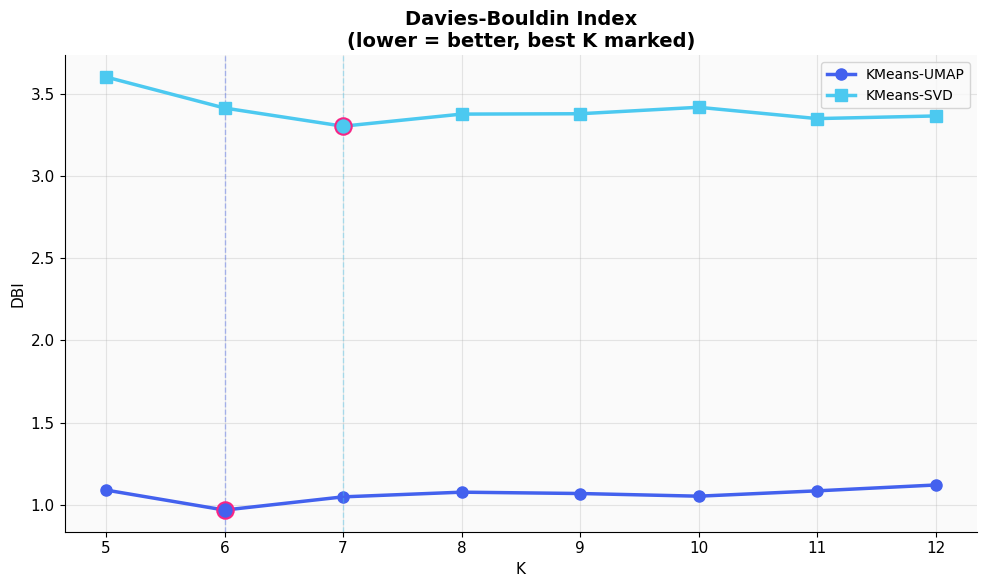

In [28]:
plot_multimodel_metric(
    records_dict=all_records,
    metric_key='davies_bouldin',
    title='Davies-Bouldin Index\n(lower = better, best K marked)',
    ylabel='DBI',
    cfg=CFG, C=C,
    higher_better=False
)

### Purity

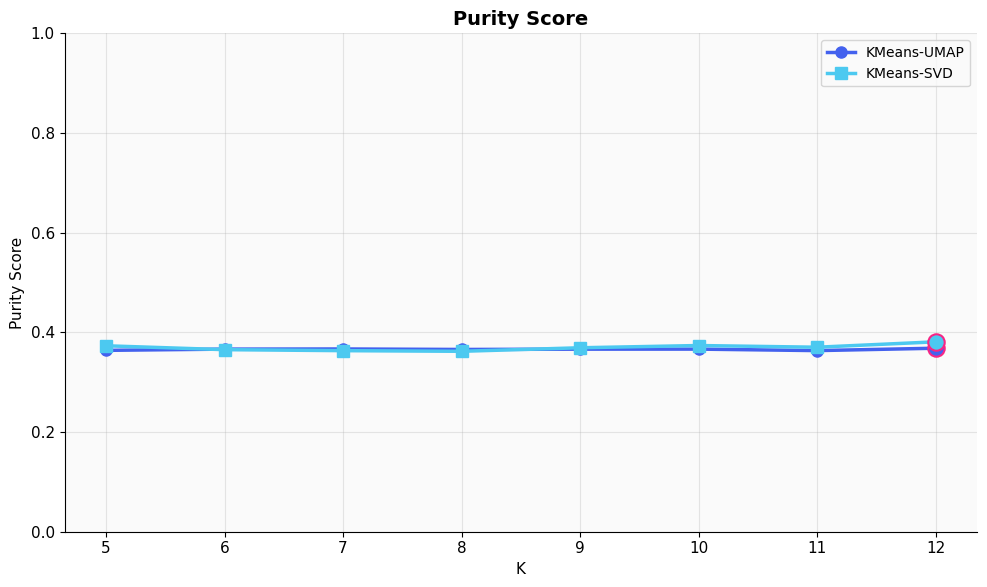

In [30]:
plot_multimodel_metric(
    records_dict=all_records,
    metric_key='purity',
    title='Purity Score',
    ylabel='Purity Score',
    cfg=CFG, C=C,
    higher_better=True,
    ylim=(0, 1)
)

### Composite

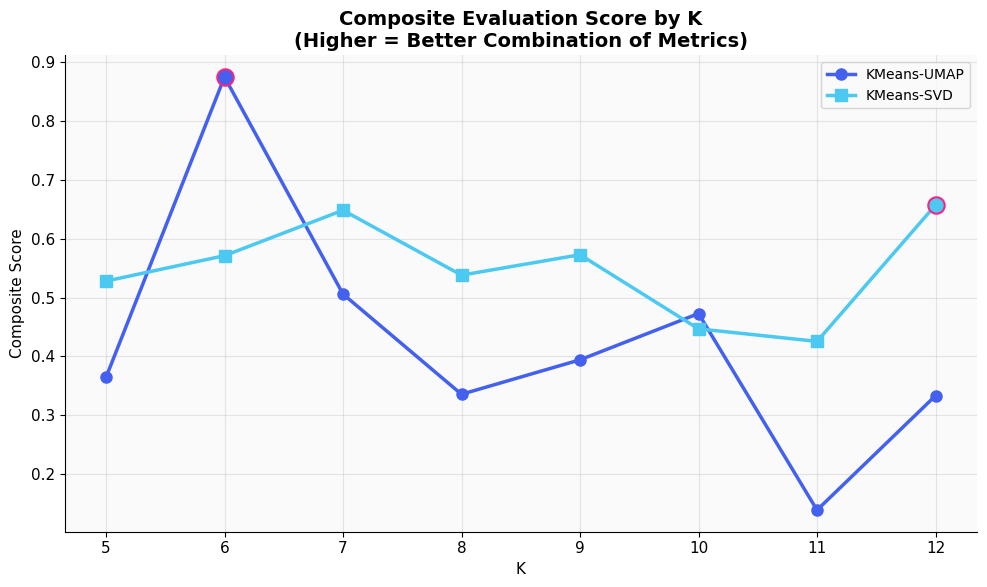

In [31]:
plot_multimodel_metric(
    records_dict=all_records,
    metric_key='composite',
    title='Composite Evaluation Score by K\n(Higher = Better Combination of Metrics)',
    ylabel='Composite Score',
    cfg=CFG, C=C,
    higher_better=True
)

Berdasarkan hasil K Sweep dari 5 sampai 12, diketahui bahwa KMeans-UMAP lebih unggul dibanding KMeans-SVD. Hal ini dapat dilihat dari hasil composite score tertinggi pada KMeans-UMAP (k=6) hampir mencapai 0.9, sedangkan composite score tertinggi pada KMeans-SVD (k=12) bahkan tidak mencapai 0.7. Maka dari itu, model KMeans-UMAP (k=6) dipilih menjadi model dari aplikasi DevType.

In [33]:
def select_best_model(records_umap, cfg):
    primary_records = records_umap
    primary_model   = 'KMeans-UMAP'

    # Sort by composite score
    sorted_by_composite = sorted(primary_records,
                                 key=lambda x: x.get('composite', 0),
                                 reverse=True)

    # Pick best balanced K
    best = None
    for r in sorted_by_composite:
        if r['balanced']:
            best = r
            break
    if best is None:
        best = sorted_by_composite[0]

    return best, primary_model

best_record, best_model_name = select_best_model(
    records_umap, CFG
)

# Update config with selected K
CFG['k_best']          = best_record['k']
CFG['best_model_name'] = best_model_name
labels_best            = best_record['labels']
km_best                = best_record['km_obj']
X_best                 = data['X_umap']

print(f"Best model selected. K={CFG['k_best']}, model={CFG['best_model_name']}")

Best model selected. K=6, model=KMeans-UMAP


# **Persona Labeling**

In [35]:
def profile_clusters(labels, X_binary, feature_names, df_meta,
                     primary_roles, cfg, top_n_skills=8):
    k = len(np.unique(labels))
    profiles = []

    print(f"CLUSTER PROFILES (K={k})\n")

    for c in range(k):
        mask  = labels == c
        n     = mask.sum()

        # Skill prevalences
        skill_means = X_binary[mask].mean(axis=0) * 100
        top_idx     = np.argsort(skill_means)[::-1][:top_n_skills]
        top_skills  = [(feature_names[i],
                        f"{skill_means[i]:.0f}%") for i in top_idx]

        # Role distribution
        role_counts = Counter(np.array(primary_roles)[mask])
        top_roles   = role_counts.most_common(3)
        dom_role    = top_roles[0][0]
        purity_c    = top_roles[0][1] / n

        # Salary insight
        meta_sub = df_meta.iloc[mask]
        sal_data = meta_sub['ConvertedCompYearly'].dropna()
        sal_data = sal_data[(sal_data > 5000) & (sal_data < 500000)]
        sal_med  = sal_data.median() if len(sal_data) >= 10 else None

        # Years of experience
        exp_data = meta_sub['YearsCode'].dropna()
        exp_med  = exp_data.median() if len(exp_data) >= 10 else None

        profiles.append({
            'cluster':      c,
            'size':         n,
            'size_pct':     n / len(labels) * 100,
            'dom_role':     dom_role,
            'purity':       purity_c,
            'top3_roles':   top_roles,
            'top_skills':   top_skills,
            'sal_median':   sal_med,
            'exp_median':   exp_med,
        })

        skill_str = ' , '.join([f"{s.split('__',1)[1]} {p}"
                                   for s, p in top_skills[:5]])
        role_str  = ' , '.join([f"{r}({cnt})" for r, cnt in top_roles[:3]])
        print(f"  Cluster {c}  n={n:,} ({n/len(labels)*100:.1f}%)"
              f"  purity={purity_c:.1%}")
        print(f"    Dominant role  : {dom_role}")
        print(f"    Top roles      : {role_str}")
        print(f"    Top skills     : {skill_str}")
        if sal_med:
            print(f"    Median salary  : ${sal_med:,.0f}/yr  (n={len(sal_data)})")
        if exp_med:
            print(f"    Median exp     : {exp_med:.0f} years coding\n")

    return profiles

profiles = profile_clusters(
    labels_best, data['X_binary'], data['feat_names'],
    data['df_meta'], primary_roles, CFG
)

CLUSTER PROFILES (K=6)

  Cluster 0  n=3,262 (13.9%)  purity=31.6%
    Dominant role  : Full-Stack
    Top roles      : Full-Stack(1031) , Back-End(989) , Other(334)
    Top skills     : Java 93% , IntelliJ IDEA 78% , Docker 74% , SQL 68% , JavaScript 67%
    Median salary  : $84,602/yr  (n=2366)
    Median exp     : 16 years coding

  Cluster 1  n=5,100 (21.8%)  purity=43.9%
    Dominant role  : Full-Stack
    Top roles      : Full-Stack(2241) , Other(792) , Back-End(767)
    Top skills     : C# 96% , Visual Studio Code 81% , Visual Studio 79% , Microsoft SQL Server 79% , SQL 78%
    Median salary  : $85,000/yr  (n=3877)
    Median exp     : 18 years coding

  Cluster 2  n=3,281 (14.0%)  purity=32.8%
    Dominant role  : Full-Stack
    Top roles      : Full-Stack(1077) , Other(471) , Back-End(349)
    Top skills     : JavaScript 91% , Docker 88% , Python 86% , npm 86% , HTML/CSS 85%
    Median salary  : $73,089/yr  (n=2014)
    Median exp     : 12 years coding

  Cluster 3  n=3,182 (1

Berdasarkan cluster yang dihasilkan model, hampir semua dominant rolenya terisi oleh Full-Stack akibat class imbalanced pada dataset. Maka dari itu, persona label akan dibuat seccara manual berdasarkan Top skills tiap cluster.

In [36]:
PERSONA_LABELS = {
    0: "Java / JVM Backend Developer",
    1: ".NET / Microsoft Ecosystem Developer",
    2: "Cloud-Native Full-Stack Developer",
    3: "PHP / LAMP Web Developer",
    4: "Python Backend & Data Developer",
    5: "Modern JavaScript / TypeScript Developer",
}

k_actual = len(np.unique(labels_best))

# Map labels ke persona names
persona_labels_arr = np.array([PERSONA_LABELS.get(c, f"Cluster {c}")
                                for c in labels_best])

print(f"Persona labels assigned for K={k_actual}:")
for c, name in sorted(PERSONA_LABELS.items()):
    if c < k_actual:
        n = (labels_best == c).sum()
        print(f"  - Cluster {c} : {name}  (n={n:,}, {n/len(labels_best)*100:.1f}%)")

Persona labels assigned for K=6:
  - Cluster 0 : Java / JVM Backend Developer  (n=3,262, 13.9%)
  - Cluster 1 : .NET / Microsoft Ecosystem Developer  (n=5,100, 21.8%)
  - Cluster 2 : Cloud-Native Full-Stack Developer  (n=3,281, 14.0%)
  - Cluster 3 : PHP / LAMP Web Developer  (n=3,182, 13.6%)
  - Cluster 4 : Python Backend & Data Developer  (n=4,236, 18.1%)
  - Cluster 5 : Modern JavaScript / TypeScript Developer  (n=4,326, 18.5%)


# **Save Model**

In [37]:
import json, numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.bool_):
            return bool(obj)
        return super().default(obj)

def save_final_model(km_best, labels_best, profiles, persona_labels,
                     df_meta, data, cfg):
    m = cfg['models_dir']
    a = cfg['artifacts_dir']

    print('Artifacts Saved: ')

    # 1. Final KMeans model
    joblib.dump(km_best, f"{a}/kmeans_final.pkl")
    print(f" - kmeans_final.pkl")

    # 2. Cluster labels aligned with respondent_ids
    label_df = pd.DataFrame({
        'ResponseId':    data['resp_ids'],
        'cluster_id':    labels_best,
        'persona_label': [persona_labels.get(c, f'Cluster {c}')
                          for c in labels_best],
    })
    label_df.to_csv(f"{m}/cluster_assignments.csv", index=False)
    print(f" - cluster_assignments.csv  ({len(label_df):,} rows)")

    # 3. Cluster profiles JSON
    profiles_json = []
    for p in profiles:
        profiles_json.append({
            'cluster_id':    int(p['cluster']),
            'persona_label': persona_labels.get(p['cluster'], f"Cluster {p['cluster']}"),
            'size':          int(p['size']),
            'size_pct':      float(round(float(p['size_pct']), 2)),
            'dom_role':      str(p['dom_role']),
            'purity':        float(round(float(p['purity']), 4)),
            'top_skills':    [
                {
                    'feature':         str(s),
                    'prevalence_pct':  float(pct.rstrip('%'))
                }
                for s, pct in p['top_skills']
            ],
            'salary_median': float(p['sal_median']) if p['sal_median'] is not None else None,
            'exp_median':    float(p['exp_median']) if p['exp_median'] is not None else None,
        })

    with open(f"{m}/cluster_profiles.json", 'w') as f:
        json.dump(profiles_json, f, indent=2, cls=NumpyEncoder)
    print(f" - cluster_profiles.json")

    # 4. Full enriched dataset
    df_enriched = df_meta.copy()
    df_enriched['cluster_id']    = labels_best
    df_enriched['persona_label'] = [persona_labels.get(c, f'Cluster {c}')
                                     for c in labels_best]
    df_enriched.to_csv(f"{m}/dataset_with_clusters.csv", index=False)
    print(f" - dataset_with_clusters.csv")

    # 5. Persona labels dict
    with open(f"{a}/persona_labels.json", 'w') as f:
        json.dump(
            {str(k): v for k, v in persona_labels.items()},
            f, indent=2, cls=NumpyEncoder
        )
    print(f" - persona_labels.json")

    # 6. Model config
    model_cfg = {
        'best_model':    cfg['best_model_name'],
        'k':             int(cfg['k_best']),
        'n_init':        int(cfg['n_init']),
        'random_state':  int(cfg['random_state']),
        'feature_count': int(len(data['feat_names'])),
        'n_respondents': int(len(labels_best)),
        'metrics': {
            'silhouette':     float(best_record['silhouette']),
            'davies_bouldin': float(best_record['davies_bouldin']),
            'purity':         float(best_record['purity']),
            'ari':            float(best_record['ari']),
        }
    }
    with open(f"{a}/model_config.json", 'w') as f:
        json.dump(model_cfg, f, indent=2, cls=NumpyEncoder)
    print(f" - model_config.json")

    return df_enriched

df_enriched = save_final_model(
    km_best, labels_best, profiles, PERSONA_LABELS,
    data['df_meta'], data, CFG
)

Artifacts Saved: 
 - kmeans_final.pkl
 - cluster_assignments.csv  (23,387 rows)
 - cluster_profiles.json
 - dataset_with_clusters.csv
 - persona_labels.json
 - model_config.json
